In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [143]:
U_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

swave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
]) * U_arr

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.100 + 1e-12, 0.001),
    np.arange(0.1005, 0.1400 + 1e-12, 0.0005),
    np.arange(0.141, 0.200 + 1e-12, 0.001),
])  # 240 temps total

U_num = len(U_arr)
temps_num = len(temps)

In [144]:
df = np.load('./data/SFP_hx_mult.npz')
temps_df = df["temps"].reshape(U_num, temps_num)
F0 = df["F0"].reshape(U_num, temps_num)
F_swave = df["F_swave"].reshape((U_num, temps_num))
F_dwave = df["F_dwave"].reshape((U_num, temps_num))
F_px = df["F_px"].reshape((U_num, temps_num))
F_py = df["F_py"].reshape((U_num, temps_num))
Fuu_px = df["Fuu_px"].reshape((U_num, temps_num))
Fuu_py = df["Fuu_py"].reshape((U_num, temps_num))
Fdd_px = df["Fdd_px"].reshape((U_num, temps_num))
Fdd_py = df["Fdd_py"].reshape((U_num, temps_num))

In [145]:
print(U_arr * F0.T[0])

[0.07912 +0.j 0.24388 +0.j 0.430788+0.j 0.626072+0.j 0.82445 +0.j
 1.1     +0.j 1.35    +0.j 1.625   +0.j 1.925   +0.j 2.25    +0.j
 2.6     +0.j 2.975   +0.j 3.375   +0.j 3.8     +0.j]


(14, 240) (14,) (14, 240)


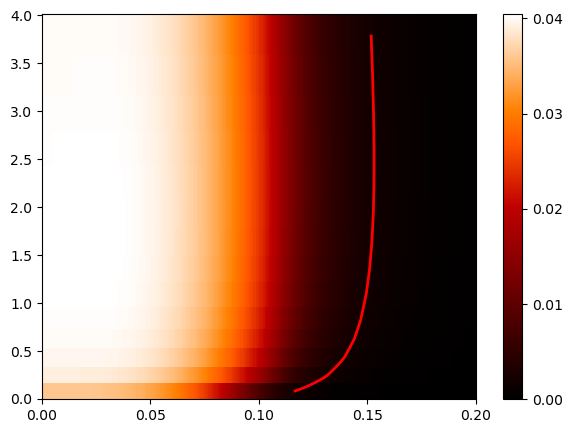

In [146]:
import numpy as np
import matplotlib.pyplot as plt

# intensity
I = np.abs(Fuu_px - Fdd_px) / 2

# threshold
threshold = 0.05 * I.max()
threshold2 = 0.01 * I.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    swave_arr,
    I,
    shading='auto',
    cmap='gist_heat'
)
print(temps_df.shape, swave_arr.shape, I.shape)
# red contour line
ax.contour(
    temps,
    swave_arr,
    I,
    levels=[threshold],
    colors='red',
    linewidths=2
)
ax.set_xlim(0, 0.2)
ax.set_xticks([0.0, 0.05, 0.1, 0.15, 0.2])

# labels
# ax.set_xlabel(r'$T/t$', fontsize=15)
# ax.set_ylabel(r'$\Delta_s$', fontsize=15)

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
# cbar.set_label(
    # r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$',
    # fontsize = 18 
# )
cbar.set_ticks([0.0, 0.01, 0.02, 0.03, 0.04])
plt.savefig('../../figures/SFP_mult.pdf', bbox_inches='tight')

plt.show()

In [2]:
V_arr = np.array([
    0,1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,
    # 9,9.5
])

dwave_arr = np.array([
    0, 0.07912, 0.12194, 0.143596,
    0.156518, 0.16489, 0.2, 0.225, 
    0.25, 0.275, 0.3, 0.325, 0.35,
    # 0.375, 0.4
])

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.080 + 1e-12, 0.01),
    np.arange(0.0805, 0.1100 + 1e-12, 0.0005),
    np.arange(0.115, 0.200 + 1e-12, 0.001),
])  # 163 temps total

temps_num = len(temps)
V_num = len(V_arr)

print(temps_num)
print(temps_num*V_num)

print(np.where(np.isclose(dwave_arr, 0.975)))
print(dwave_arr)

163
2119
(array([], dtype=int64),)
[0.       0.07912  0.12194  0.143596 0.156518 0.16489  0.2      0.225
 0.25     0.275    0.3      0.325    0.35    ]


In [11]:
df = np.load('./data/DFP_hx_mult.npz')
temps_df = df["temps"].reshape(V_num, temps_num)
F0 = df["F0"].reshape(V_num, temps_num)
F_swave = df["F_swave"].reshape((V_num, temps_num))
F_dwave = df["F_dwave"].reshape((V_num, temps_num))
F_px = df["F_px"].reshape((V_num, temps_num))
F_py = df["F_py"].reshape((V_num, temps_num))
Fuu_px = df["Fuu_px"].reshape((V_num, temps_num))
Fuu_py = df["Fuu_py"].reshape((V_num, temps_num))
Fdd_px = df["Fdd_px"].reshape((V_num, temps_num))
Fdd_py = df["Fdd_py"].reshape((V_num, temps_num))

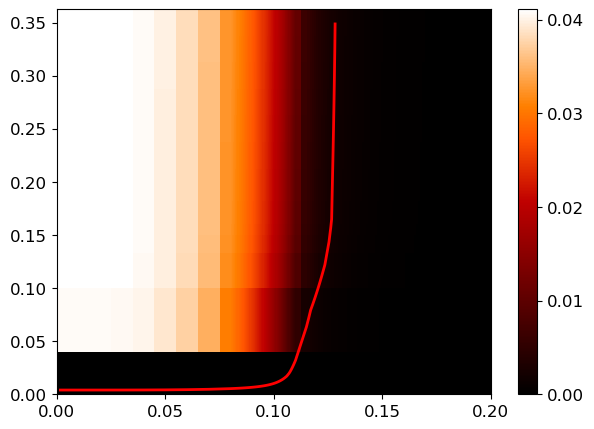

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# intensity
I = np.abs(Fuu_px - Fdd_px) / 2

# threshold
threshold = 0.05 * I.max()
threshold2 = 0.01 * I.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    dwave_arr,
    I,
    shading='auto',
    cmap='gist_heat',
)
ax.set_xlim(0, 0.2)

# red contour line
ax.contour(
    temps,
    dwave_arr,
    I,
    levels=[threshold],
    colors='red',
    linewidths=2
)

ax.set_xlim(0, 0.2)
ax.set_xticks([0.0, 0.05, 0.1, 0.15, 0.2])

# labels
# ax.set_xlabel(r'$T/t$', fontsize=15)
# ax.set_ylabel(r'$\Delta_d$', fontsize=15)
ax.tick_params(labelsize=12)
# colorbar
cbar = fig.colorbar(pcm, ax=ax)
# cbar.set_label(
#     r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$',
#     fontsize = 18 
# )
cbar.set_ticks([0.0, 0.01, 0.02, 0.03, 0.04])
cbar.ax.tick_params(labelsize=12)
plt.ylim(0, None)
plt.savefig('../../figures/DFP_mult.pdf', bbox_inches='tight')
plt.show()

In [150]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
])

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.10 + 1e-12, 0.01),
    np.arange(0.110, 0.300 + 1e-12, 0.001),
])  # 210 temps total

temps_num = len(temps)
V_num = len(V_arr)

print(np.where(np.isclose(temps, 0.2)))

(array([109]),)


In [151]:
df25 = np.load('./data/DFP_hx_mult_V25.npz')
temps_df25 = df25["temps"].reshape(V_num, temps_num)
F0 = df25["F0"].reshape(V_num, temps_num)
F_swave25 = df25["F_swave"].reshape((V_num, temps_num))
F_dwave25 = df25["F_dwave"].reshape((V_num, temps_num))
F_px25 = df25["F_px"].reshape((V_num, temps_num))
F_py25 = df25["F_py"].reshape((V_num, temps_num))
Fuu_px25 = df25["Fuu_px"].reshape((V_num, temps_num))
Fuu_py25 = df25["Fuu_py"].reshape((V_num, temps_num))
Fdd_px25 = df25["Fdd_px"].reshape((V_num, temps_num))
Fdd_py25 = df25["Fdd_py"].reshape((V_num, temps_num))

(14, 210) (14,) (14, 210)


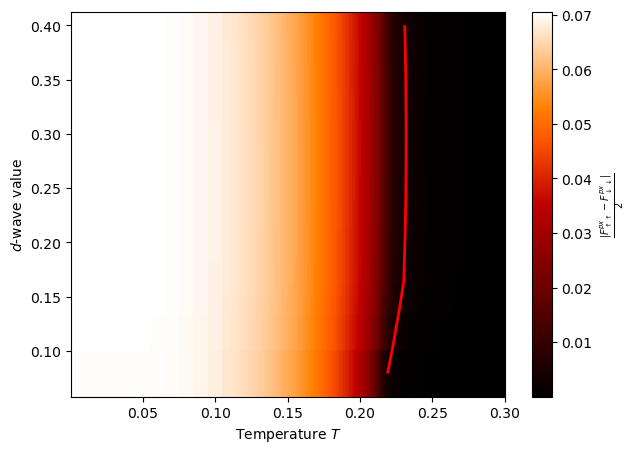

In [152]:
import numpy as np
import matplotlib.pyplot as plt

# intensity
I25 = np.abs(Fuu_px25 - Fdd_px25) / 2

# threshold
threshold = 0.05 * I25.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    dwave_arr,
    I25,
    shading='auto',
    cmap='gist_heat'
)
print(temps_df25.shape, dwave_arr.shape, I25.shape)
# red contour line
ax.contour(
    temps,
    dwave_arr,
    I25,
    levels=[threshold],
    colors='red',
    linewidths=2
)
# ax.set_xlim(0, 0.2)

# labels
ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'$d$-wave value')

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(
    r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$'
)

plt.show()

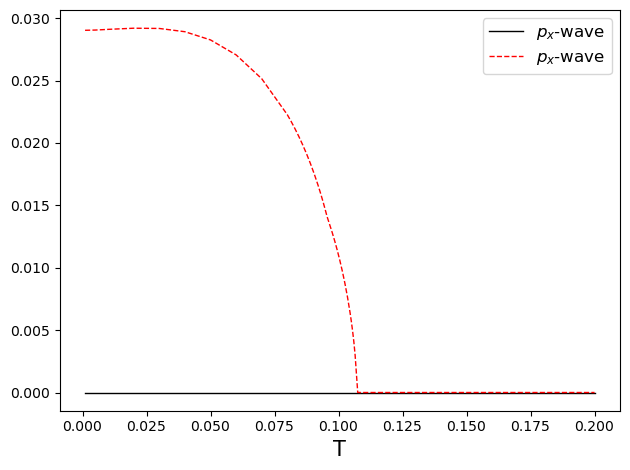

In [13]:
plt.figure(1)
plt.clf()

plt.plot(temps_df[0], np.abs(Fuu_px[0]-Fdd_px[0])/2, linewidth=1, label=r"$p_x$-wave", color='black')
plt.plot(temps_df[0], np.abs(Fuu_py[0]+Fdd_px[0])/2, "--", linewidth=1, label=r"$p_x$-wave", color='red')

# plt.ylim(0,0.05)
# plt.xlim(0,0.2)
plt.xlabel("T", fontsize=15)
plt.legend(loc="best", fontsize=12)
plt.tight_layout()
plt.show()

In [154]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
])

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.10 + 1e-12, 0.01),
    np.arange(0.11, 0.30 + 1e-12, 0.01),
    np.arange(0.301, 0.450 + 1e-12, 0.001),
    np.arange(0.460, 0.500 + 1e-12, 0.01),
])  # 194 temps total


temps_num = len(temps)
V_num = len(V_arr)

print(np.where(np.isclose(temps, 0.2)))

(array([28]),)


In [155]:
df30 = np.load('./data/DFP_hx_mult_V30.npz')
temps_df30 = df30["temps"].reshape(V_num, temps_num)
F0 = df30["F0"].reshape(V_num, temps_num)
F_swave30 = df30["F_swave"].reshape((V_num, temps_num))
F_dwave30 = df30["F_dwave"].reshape((V_num, temps_num))
F_px30 = df30["F_px"].reshape((V_num, temps_num))
F_py30 = df30["F_py"].reshape((V_num, temps_num))
Fuu_px30 = df30["Fuu_px"].reshape((V_num, temps_num))
Fuu_py30 = df30["Fuu_py"].reshape((V_num, temps_num))
Fdd_px30 = df30["Fdd_px"].reshape((V_num, temps_num))
Fdd_py30 = df30["Fdd_py"].reshape((V_num, temps_num))

(14, 194) (14,) (14, 194)


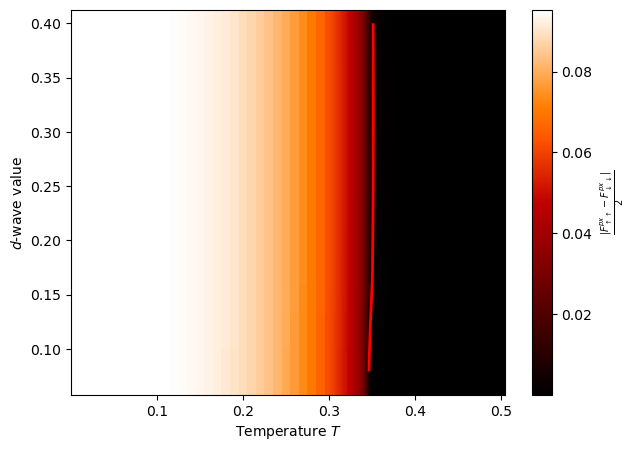

In [156]:
import numpy as np
import matplotlib.pyplot as plt

# intensity
I30 = np.abs(Fuu_px30 - Fdd_px30) / 2

# threshold
threshold = 0.05 * I30.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    dwave_arr,
    I30,
    shading='auto',
    cmap='gist_heat'
)
print(temps_df30.shape, dwave_arr.shape, I30.shape)
# red contour line
ax.contour(
    temps,
    dwave_arr,
    I30,
    levels=[threshold],
    colors='red',
    linewidths=2
)
# ax.set_xlim(0, 0.2)

# labels
ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'$d$-wave value')

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(
    r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$'
)

plt.show()

In [157]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
])

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.35 + 1e-12, 0.01),
    np.arange(0.355, 0.450 + 1e-12, 0.005),
    np.arange(0.451, 0.550 + 1e-12, 0.001),
    np.arange(0.555, 0.600 + 1e-12, 0.005),
])  # 174 temps total

temps_num = len(temps)
V_num = len(V_arr)

print(np.where(np.isclose(temps, 0.2)))

(array([28]),)


In [158]:
df35 = np.load('./data/DFP_hx_mult_V35.npz')
temps_df35 = df35["temps"].reshape(V_num, temps_num)
F0 = df35["F0"].reshape(V_num, temps_num)
F_swave35 = df35["F_swave"].reshape((V_num, temps_num))
F_dwave35 = df35["F_dwave"].reshape((V_num, temps_num))
F_px35 = df35["F_px"].reshape((V_num, temps_num))
F_py35 = df35["F_py"].reshape((V_num, temps_num))
Fuu_px35 = df35["Fuu_px"].reshape((V_num, temps_num))
Fuu_py35 = df35["Fuu_py"].reshape((V_num, temps_num))
Fdd_px35 = df35["Fdd_px"].reshape((V_num, temps_num))
Fdd_py35 = df35["Fdd_py"].reshape((V_num, temps_num))

(14, 174) (14,) (14, 174)


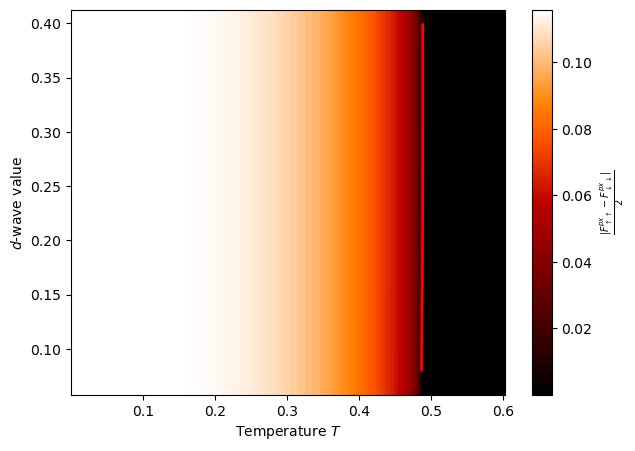

In [159]:
import numpy as np
import matplotlib.pyplot as plt

# intensity
I35 = np.abs(Fuu_px35 - Fdd_px35) / 2

# threshold
threshold = 0.05 * I35.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    dwave_arr,
    I35,
    shading='auto',
    cmap='gist_heat'
)
print(temps_df35.shape, dwave_arr.shape, I35.shape)
# red contour line
ax.contour(
    temps,
    dwave_arr,
    I35,
    levels=[threshold],
    colors='red',
    linewidths=2
)
# ax.set_xlim(0, 0.2)

# labels
ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'$d$-wave value')

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(
    r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$'
)

plt.show()

In [160]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
])

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.550 + 1e-12, 0.01),
    np.arange(0.555, 0.600 + 1e-12, 0.005),
    np.arange(0.601, 0.700 + 1e-12, 0.001),
    np.arange(0.705, 0.750 + 1e-12, 0.005),
])  # 184 temps total

temps_num = len(temps)
V_num = len(V_arr)

print(np.where(np.isclose(temps, 0.2)))

(array([28]),)


In [161]:
df40 = np.load('./data/DFP_hx_mult_V40.npz')
temps_df40 = df40["temps"].reshape(V_num, temps_num)
F0 = df40["F0"].reshape(V_num, temps_num)
F_swave40 = df40["F_swave"].reshape((V_num, temps_num))
F_dwave40 = df40["F_dwave"].reshape((V_num, temps_num))
F_px40 = df40["F_px"].reshape((V_num, temps_num))
F_py40 = df40["F_py"].reshape((V_num, temps_num))
Fuu_px40 = df40["Fuu_px"].reshape((V_num, temps_num))
Fuu_py40 = df40["Fuu_py"].reshape((V_num, temps_num))
Fdd_px40 = df40["Fdd_px"].reshape((V_num, temps_num))
Fdd_py40 = df40["Fdd_py"].reshape((V_num, temps_num))

(14, 184) (14,) (14, 184)


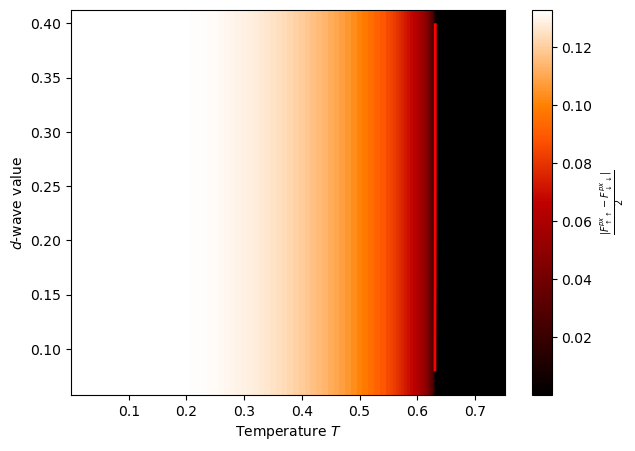

In [162]:
import numpy as np
import matplotlib.pyplot as plt

# intensity
I40 = np.abs(Fuu_px40 - Fdd_px40) / 2

# threshold
threshold = 0.05 * I40.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    dwave_arr,
    I40,
    shading='auto',
    cmap='gist_heat'
)
print(temps_df40.shape, dwave_arr.shape, I40.shape)
# red contour line
ax.contour(
    temps,
    dwave_arr,
    I40,
    levels=[threshold],
    colors='red',
    linewidths=2
)
# ax.set_xlim(0, 0.2)

# labels
ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'$d$-wave value')

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(
    r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$'
)

plt.show()

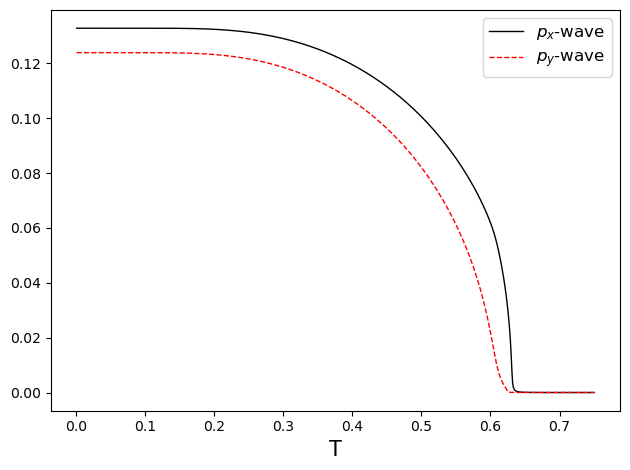

In [163]:
plt.figure(1)
plt.clf()

plt.plot(temps_df40[-1], np.abs(Fuu_px40[-1]-Fdd_px40[-1])/2, linewidth=1, label=r"$p_x$-wave", color='black')
plt.plot(temps_df40[-1], np.abs(Fuu_py40[-1]-Fdd_py40[-1])/2, "--", linewidth=1, label=r"$p_y$-wave", color='red')

# plt.ylim(0,0.05)
# plt.xlim(0,0.2)
plt.xlabel("T", fontsize=15)
plt.legend(loc="best", fontsize=12)
plt.tight_layout()
plt.show()

In [164]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.080 + 1e-12, 0.01),
    np.arange(0.0805, 0.1100 + 1e-12, 0.0005),
    np.arange(0.115, 0.300 + 1e-12, 0.001),
])  # 263 temps total
hmag_arr = np.linspace(0.5, 2, 10)

temps_num = len(temps)
hmag_num = len(hmag_arr)

[0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j
 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.3+0.j 0.

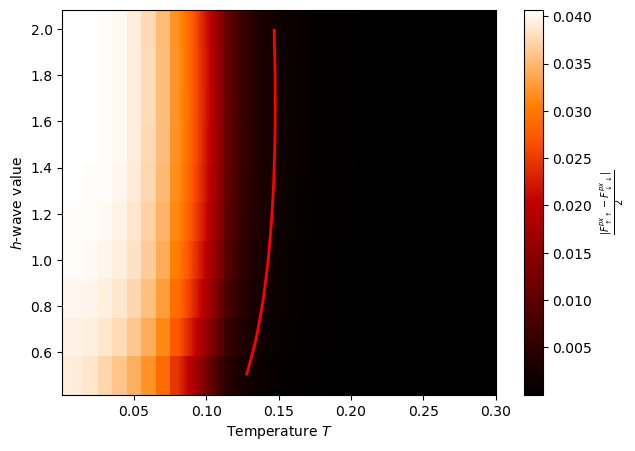

In [165]:
import numpy as np
import matplotlib.pyplot as plt



df40 = np.load('./data/DFP_hxmag.npz')
temps_df40 = df40["temps"].reshape(hmag_num, temps_num)
F0 = df40["F0"].reshape(hmag_num, temps_num)
F_swave40 = df40["F_swave"].reshape((hmag_num, temps_num))
F_dwave40 = df40["F_dwave"].reshape((hmag_num, temps_num))
F_px40 = df40["F_px"].reshape((hmag_num, temps_num))
F_py40 = df40["F_py"].reshape((hmag_num, temps_num))
Fuu_px40 = df40["Fuu_px"].reshape((hmag_num, temps_num))
Fuu_py40 = df40["Fuu_py"].reshape((hmag_num, temps_num))
Fdd_px40 = df40["Fdd_px"].reshape((hmag_num, temps_num))
Fdd_py40 = df40["Fdd_py"].reshape((hmag_num, temps_num))
print(F_dwave40[0])
# intensity
I40 = np.abs(Fuu_px40 - Fdd_px40) / 2

# threshold
threshold = 0.05 * I40.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    hmag_arr,
    I40,
    shading='auto',
    cmap='gist_heat'
)
print(temps_df40.shape, hmag_arr.shape, I40.shape)
# red contour line
ax.contour(
    temps,
    hmag_arr,
    I40,
    levels=[threshold],
    colors='red',
    linewidths=2
)
# ax.set_xlim(0, 0.2)

# labels
ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'$h$-wave value')

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(
    r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$'
)

plt.show()